<a href="https://colab.research.google.com/github/joyjit-das/sof-tiu-ai-lab/blob/main/ai_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 3: Checking Routes Between Cities Using DFS
Problem Statement:
A small road network connects several cities. Write a Python program using DFS that:
1. Checks whether a route exists between two given cities.
2. Finds all separate groups of cities that are connected to each other but not to any
other group (these are called connected components).

1. Direct Route Checks (No intermediate cities):
   Seattle -> San Francisco: True
   Seattle -> New York:      False

2. General Reachability Checks (DFS):
   Boston -> Washington DC:  True
   Boston -> London:         False

3. Connected Components (Isolated City Groups):
   Group 1: Seattle, Los Angeles, San Francisco
   Group 2: New York, Washington DC, Boston
   Group 3: Paris, London


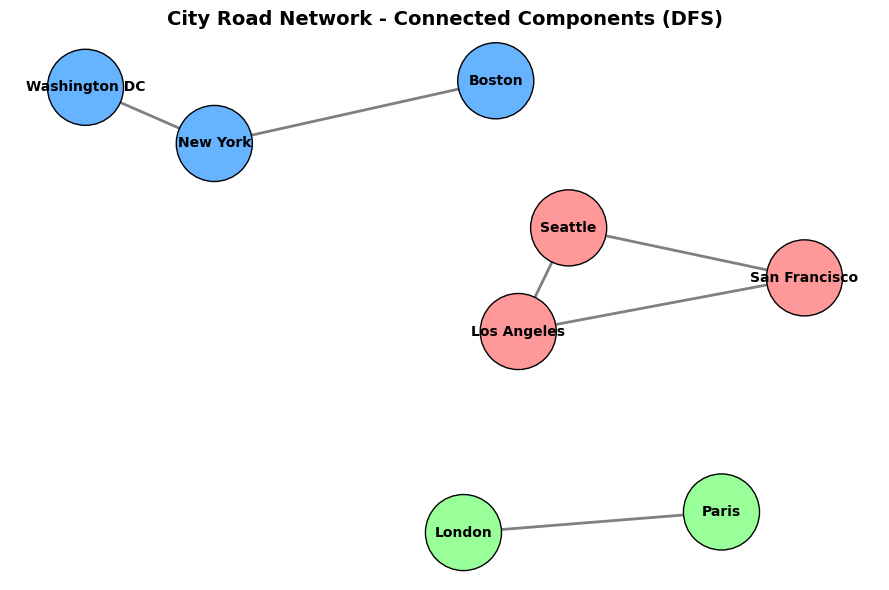

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Road Network represented as an Undirected Graph (Adjacency List)
# Contains 3 separate connected components
city_graph = {
    # Component 1: US West Coast
    'Seattle': ['San Francisco', 'Los Angeles'],
    'San Francisco': ['Seattle', 'Los Angeles'],
    'Los Angeles': ['Seattle', 'San Francisco'],

    # Component 2: US East Coast
    'New York': ['Boston', 'Washington DC'],
    'Boston': ['New York'],
    'Washington DC': ['New York'],

    # Component 3: Isolated European Cities
    'Paris': ['London'],
    'London': ['Paris']
}

# Check direct connection (no city in between)
def has_direct_route(graph, city1, city2):
    return city2 in graph.get(city1, [])

# Check general route reachability using DFS
def has_route_dfs(graph, start, destination, visited=None):
    if visited is None:
        visited = set()

    if start == destination:
        return True

    visited.add(start)
    for neighbor in graph.get(start, []):
        if neighbor not in visited:
            if has_route_dfs(graph, neighbor, destination, visited):
                return True
    return False

# Find all connected components using DFS
def find_connected_components(graph):
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            component = []
            # Internal DFS helper
            stack = [city]
            while stack:
                node = stack.pop()
                if node not in visited:
                    visited.add(node)
                    component.append(node)
                    for neighbor in graph[node]:
                        if neighbor not in visited:
                            stack.append(neighbor)
            components.append(component)

    return components

# --- Running Queries ---
print("1. Direct Route Checks (No intermediate cities):")
print(f"   Seattle -> San Francisco: {has_direct_route(city_graph, 'Seattle', 'San Francisco')}")
print(f"   Seattle -> New York:      {has_direct_route(city_graph, 'Seattle', 'New York')}\n")

print("2. General Reachability Checks (DFS):")
print(f"   Boston -> Washington DC:  {has_route_dfs(city_graph, 'Boston', 'Washington DC')}")
print(f"   Boston -> London:         {has_route_dfs(city_graph, 'Boston', 'London')}\n")

components = find_connected_components(city_graph)
print("3. Connected Components (Isolated City Groups):")
for i, comp in enumerate(components, 1):
    print(f"   Group {i}: {', '.join(comp)}")

# --- Visualization Function ---
def draw_city_network(graph, components):
    G = nx.Graph(graph)

    # Color map for distinct connected components
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    node_color_map = {}

    for idx, comp in enumerate(components):
        for city in comp:
            node_color_map[city] = colors[idx % len(colors)]

    color_list = [node_color_map[node] for node in G.nodes()]

    plt.figure(figsize=(9, 6))
    pos = nx.spring_layout(G, seed=42, k=1.2)

    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=color_list, edgecolors='black')
    nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title("City Road Network - Connected Components (DFS)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Render Diagram
draw_city_network(city_graph, components)